# Project 1. Heart Attack Risk Prediction

**Цель:** Разработать модель для предсказания риска сердечного приступа на основе данных пациентов

**Задачи:**
1. Исследование датасета
2. Предобработка данных
3. Обучение модели
4. Подготовка предсказания на тестовой выборке

**План работы:**
* Загрузка и изучение данных 
* Предобработка данных
* Исследовательский анализ данных
* Корреляционный анализ данных
* Использование пайплайнов для нахождения лучшей модели
* Анализ важности данных
* Подготовка предсказания на тестовой выборке
* Общие выводы

## Загрузка данных

Импортируем необходимые для дальнейшей работы библиотеки

In [1]:
!pip install phik -q
!pip install shap -q
!pip install -U scikit-learn

import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
import shap
from phik import phik_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, MinMaxScaler
from joblib import dump

In [2]:
df_train = pd.read_csv('heart_train.csv')
df_test = pd.read_csv('heart_test.csv')

# Устанавливаем неограниченное количество отображаемых столбцов 
pd.set_option('display.max_columns', None)

In [3]:
# общая информация и первые 5 строк первого датафрейма 
print(df_train.info())
df_train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8685 entries, 0 to 8684
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       8685 non-null   int64  
 1   Age                              8685 non-null   float64
 2   Cholesterol                      8685 non-null   float64
 3   Heart rate                       8685 non-null   float64
 4   Diabetes                         8442 non-null   float64
 5   Family History                   8442 non-null   float64
 6   Smoking                          8442 non-null   float64
 7   Obesity                          8442 non-null   float64
 8   Alcohol Consumption              8442 non-null   float64
 9   Exercise Hours Per Week          8685 non-null   float64
 10  Diet                             8685 non-null   int64  
 11  Previous Heart Problems          8442 non-null   float64
 12  Medication Use      

,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure,id
0,0,0.359551,0.732143,0.074244,1.0,1.0,1.0,1.0,1.0,0.535505,1,1.0,0.0,8.0,0.225704,0.105948,0.459176,0.979221,3.0,0.333333,0.0,0.227018,0.048229,0.036512,Male,0.212903,0.709302,2664
1,1,0.202247,0.325000,0.047663,1.0,1.0,0.0,0.0,1.0,0.068690,2,1.0,0.0,9.0,0.289923,0.164217,0.117053,0.515584,3.0,0.833333,0.0,0.150198,0.017616,0.000194,Female,0.412903,0.569767,9287
2,2,0.606742,0.860714,0.055912,1.0,0.0,1.0,1.0,1.0,0.944001,2,1.0,1.0,6.0,0.550133,0.598745,0.373574,0.012987,2.0,1.000000,0.0,0.227018,0.048229,0.036512,Female,0.238710,0.220930,5379
3,3,0.730337,0.007143,0.053162,0.0,0.0,1.0,0.0,1.0,0.697023,0,0.0,1.0,3.0,0.330962,0.077605,0.049735,0.131169,0.0,0.333333,1.0,0.227018,0.048229,0.036512,Female,0.348387,0.267442,8222
4,4,0.775281,0.757143,0.021998,0.0,0.0,1.0,0.0,1.0,0.412878,1,0.0,0.0,8.0,0.524600,0.341960,0.830405,0.070130,5.0,1.000000,1.0,0.227018,0.048229,0.036512,Male,0.619355,0.441860,4047


В первой таблице представлены тренировочные данные для предсказания риска сердечного приступа. Всего 8685 строк и 28 столбцов, в которых содержатся антропометрические данные пациентов, информация о привычках, давлении, наличиихронических заболеваний, биохимии крови, а также целевой признак - **риск  поражения сердца**.

В таблице есть пропущенные значения, типы данных не всегда корректны. Также названия столбцов недостаточно удобны для работы, поэтому в дальнейшем мы их скорректируем.  

In [4]:
# общая информация и первые 5 строк второго датафрейма 
print(df_test.info())
df_test.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       966 non-null    int64  
 1   Age                              966 non-null    float64
 2   Cholesterol                      966 non-null    float64
 3   Heart rate                       966 non-null    float64
 4   Diabetes                         935 non-null    float64
 5   Family History                   935 non-null    float64
 6   Smoking                          935 non-null    float64
 7   Obesity                          935 non-null    float64
 8   Alcohol Consumption              935 non-null    float64
 9   Exercise Hours Per Week          966 non-null    float64
 10  Diet                             966 non-null    int64  
 11  Previous Heart Problems          935 non-null    float64
 12  Medication Use        

,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure,id
0,0,0.494382,0.264286,0.062328,0.0,1.0,1.0,1.0,1.0,0.361618,2,0.0,0.0,8.0,0.194370,0.587759,0.283490,0.306494,1.0,0.333333,0.227018,0.048229,0.036512,Male,0.283871,0.372093,7746
1,1,0.224719,0.953571,0.082493,1.0,0.0,0.0,1.0,0.0,0.996483,2,1.0,1.0,5.0,0.329888,0.602883,0.467036,0.087013,0.0,0.166667,0.227018,0.048229,0.036512,Female,0.703226,0.441860,4202
2,2,0.629213,0.092857,0.064161,0.0,1.0,1.0,1.0,0.0,0.995561,0,0.0,0.0,10.0,0.780075,0.370436,0.409366,0.205195,7.0,1.000000,0.102767,0.002666,0.088455,Male,0.458065,0.779070,6632
3,3,0.460674,0.567857,0.055912,1.0,1.0,1.0,1.0,1.0,0.437277,0,0.0,0.0,10.0,0.785071,0.368242,0.910261,0.163636,0.0,0.666667,0.203557,0.056390,0.271774,Female,0.741935,0.255814,4639
4,4,0.719101,0.485714,0.022915,1.0,0.0,1.0,0.0,1.0,0.514920,0,0.0,0.0,7.0,0.070919,0.729578,0.758924,0.580519,5.0,0.000000,0.227018,0.048229,0.036512,Male,0.412903,0.395349,4825


Во втором датафрейме представлена уже тестовая выборка, содержащая данные пациентов. Всего 966 строк и 26 столбцов со входными признаками. Названия столбцов и типы данных такие же как и в первом датафрейме. Также есть пропущенные значения. 

**Выводы:** Загрузили 2 таблицы с тренировочными и тестовыми данными, проверили корректность данных и их соотвествию описанию. В результате были обнаружены следующие проблемы: неудобные названия столбцов, пропуски и некорректные типы данных. Необходимо провести предобработку данных. 

## Предобработка данных 

В обеих таблицах первый столбец не несет никакой полезной информации, являясь нумерацией строк. Также из перечисленных признаков не влияет на риск сердечного приступа доход **Income**. Социально-экономический статус может косвенно влиять на доступ к медицинской помощи и здоровому образу жизни, но сам по себе доход не является прямым фактором риска сердечного приступа. Удалим оба столбца из таблиц.

Кроме того, **CK-MB** (креатинкиназа-МВ) и **Troponin** (тропонин) - это биомаркеры повреждения сердечной мышцы, которые повышаются при инфаркте миокарда, но сами по себе не является фактором риска его развития. Это показатели уже имеющегося повреждения, а не причины заболевания. Для избежания косвенной утечки целевого признака удалим также и столбцы с этими данными.

In [5]:
df_train = df_train.drop(['Unnamed: 0', 'Income', 'CK-MB', 'Troponin'], axis=1, inplace=False)
df_train.head()

,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,Gender,Systolic blood pressure,Diastolic blood pressure,id
0,0.359551,0.732143,0.074244,1.0,1.0,1.0,1.0,1.0,0.535505,1,1.0,0.0,8.0,0.225704,0.459176,0.979221,3.0,0.333333,0.0,0.227018,Male,0.212903,0.709302,2664
1,0.202247,0.325000,0.047663,1.0,1.0,0.0,0.0,1.0,0.068690,2,1.0,0.0,9.0,0.289923,0.117053,0.515584,3.0,0.833333,0.0,0.150198,Female,0.412903,0.569767,9287
2,0.606742,0.860714,0.055912,1.0,0.0,1.0,1.0,1.0,0.944001,2,1.0,1.0,6.0,0.550133,0.373574,0.012987,2.0,1.000000,0.0,0.227018,Female,0.238710,0.220930,5379
3,0.730337,0.007143,0.053162,0.0,0.0,1.0,0.0,1.0,0.697023,0,0.0,1.0,3.0,0.330962,0.049735,0.131169,0.0,0.333333,1.0,0.227018,Female,0.348387,0.267442,8222
4,0.775281,0.757143,0.021998,0.0,0.0,1.0,0.0,1.0,0.412878,1,0.0,0.0,8.0,0.524600,0.830405,0.070130,5.0,1.000000,1.0,0.227018,Male,0.619355,0.441860,4047


In [6]:
df_test = df_test.drop(['Unnamed: 0', 'Income','CK-MB', 'Troponin'], axis=1, inplace=False)
df_test.head()

,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Blood sugar,Gender,Systolic blood pressure,Diastolic blood pressure,id
0,0.494382,0.264286,0.062328,0.0,1.0,1.0,1.0,1.0,0.361618,2,0.0,0.0,8.0,0.194370,0.283490,0.306494,1.0,0.333333,0.227018,Male,0.283871,0.372093,7746
1,0.224719,0.953571,0.082493,1.0,0.0,0.0,1.0,0.0,0.996483,2,1.0,1.0,5.0,0.329888,0.467036,0.087013,0.0,0.166667,0.227018,Female,0.703226,0.441860,4202
2,0.629213,0.092857,0.064161,0.0,1.0,1.0,1.0,0.0,0.995561,0,0.0,0.0,10.0,0.780075,0.409366,0.205195,7.0,1.000000,0.102767,Male,0.458065,0.779070,6632
3,0.460674,0.567857,0.055912,1.0,1.0,1.0,1.0,1.0,0.437277,0,0.0,0.0,10.0,0.785071,0.910261,0.163636,0.0,0.666667,0.203557,Female,0.741935,0.255814,4639
4,0.719101,0.485714,0.022915,1.0,0.0,1.0,0.0,1.0,0.514920,0,0.0,0.0,7.0,0.070919,0.758924,0.580519,5.0,0.000000,0.227018,Male,0.412903,0.395349,4825


### Изменение названий столбцов

Изменим названия столбцов на более удобные в дальнейшем использовании. Для единообразия в записи используем нижний регистр и подчеркивания вместо пробелов. Также уберем лишние детали из названия целевого признака.   

In [7]:
df_train.columns = df_train.columns.str.replace(' ', '_').str.lower()
df_train = df_train.rename(columns = {'heart_attack_risk_(binary)':'heart_attack_risk'})
# выводим список всех имён столбцов для проверки
print(df_train.columns.tolist())

['age', 'cholesterol', 'heart_rate', 'diabetes', 'family_history', 'smoking', 'obesity', 'alcohol_consumption', 'exercise_hours_per_week', 'diet', 'previous_heart_problems', 'medication_use', 'stress_level', 'sedentary_hours_per_day', 'bmi', 'triglycerides', 'physical_activity_days_per_week', 'sleep_hours_per_day', 'heart_attack_risk', 'blood_sugar', 'gender', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'id']


In [8]:
df_test.columns = df_test.columns.str.replace(' ', '_').str.lower()
print(df_test.columns.tolist())

['age', 'cholesterol', 'heart_rate', 'diabetes', 'family_history', 'smoking', 'obesity', 'alcohol_consumption', 'exercise_hours_per_week', 'diet', 'previous_heart_problems', 'medication_use', 'stress_level', 'sedentary_hours_per_day', 'bmi', 'triglycerides', 'physical_activity_days_per_week', 'sleep_hours_per_day', 'blood_sugar', 'gender', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'id']


### Обработка пропущенных значений

Выведем суммарное количество пропусков для каждого столбца 

In [9]:
# для тренировочной выборки 
df_train.isna().sum()

age                                  0
cholesterol                          0
heart_rate                           0
diabetes                           243
family_history                     243
smoking                            243
obesity                            243
alcohol_consumption                243
exercise_hours_per_week              0
diet                                 0
previous_heart_problems            243
medication_use                     243
stress_level                       243
sedentary_hours_per_day              0
bmi                                  0
triglycerides                        0
physical_activity_days_per_week    243
sleep_hours_per_day                  0
heart_attack_risk                    0
blood_sugar                          0
gender                               0
systolic_blood_pressure              0
diastolic_blood_pressure             0
id                                   0
dtype: int64

In [10]:
# для тестовой выборки 
df_test.isna().sum()

age                                 0
cholesterol                         0
heart_rate                          0
diabetes                           31
family_history                     31
smoking                            31
obesity                            31
alcohol_consumption                31
exercise_hours_per_week             0
diet                                0
previous_heart_problems            31
medication_use                     31
stress_level                       31
sedentary_hours_per_day             0
bmi                                 0
triglycerides                       0
physical_activity_days_per_week    31
sleep_hours_per_day                 0
blood_sugar                         0
gender                              0
systolic_blood_pressure             0
diastolic_blood_pressure            0
id                                  0
dtype: int64

В обеих таблицах пропуски есть в столбцах с следующей информацией: наличие диабета, наследственные заболевания, курение, ожирение, употребление алкоголя, предыдущие проблемы с сердцем, употребление лекарств, уровень стресса и количество активных дней в неделю. Это может быть связано с как с техническими сбоями при переносе данных, так и незаполнением анкет пациентами.    

In [11]:
print(f'Cтрок с пропусками в тренировочной выборке: {((df_train.isna().any(axis=1).sum() / len(df_train)) * 100).round(2)}%')
print(f'Cтрок с пропусками в тестовой выборке: {((df_test.isna().any(axis=1).sum() / len(df_test)) * 100).round(2)}%')

Cтрок с пропусками в тренировочной выборке: 2.8%
Cтрок с пропусками в тестовой выборке: 3.21%


В обоих выборках пациентов с неполной информацией меньше 5 процентов. Заменим пропуски в столбцах с бинарными категориальными признаками - модой, а с столбцах с целочисленными значениями - медианой, т.к. она более устойчива к выбросам.  

In [12]:
# столбцы с бинарными категориальными признаками
cat_cols = ['diabetes', 'family_history', 'smoking', 'obesity', 'alcohol_consumption', 'previous_heart_problems', 'medication_use']
# столбцы с целочисленными признаками
int_cols = ['stress_level', 'physical_activity_days_per_week']

In [13]:
# моды для каждого столбца тренировочной выборки
train_modes = {}
for col in cat_cols:
    mode_val = df_train[col].mode()
    train_modes[col] = mode_val.iloc[0]

# заменяем пропуски на моды из каждого столбцы
df_train[cat_cols] = df_train[cat_cols].fillna(train_modes)
df_test[cat_cols] = df_test[cat_cols].fillna(train_modes)

In [14]:
# медианы для каждого столбца тренировочной выборки
train_medians = {}
for col in int_cols:
    median_val = df_train[col].median()
    train_medians[col] = median_val

# заменяем пропуски на медианы из каждого столбцы
df_train[int_cols] = df_train[int_cols].fillna(train_medians)
df_test[int_cols] = df_test[int_cols].fillna(train_medians)   

Проверим снова количество пропусков в выборках

In [15]:
print(f'Суммарное количество пропусков в тренировочной выборке: {df_train.isna().sum().sum()}')
print(f'Суммарное количество пропусков в тестовой выборке: {df_test.isna().sum().sum()}')

Суммарное количество пропусков в тренировочной выборке: 0
Суммарное количество пропусков в тестовой выборке: 0


### Обработка дубликатов

In [16]:
# выведем суммарное количество явных дубликатов 
print(f'В первом датафрейме {df_train.duplicated().sum()} дубликатов') 
print(f'Во втором датафрейме {df_test.duplicated().sum()} дубликатов') 

В первом датафрейме 0 дубликатов
Во втором датафрейме 0 дубликатов


Дополнительно проверим, чтобы в столбце "id" были уникальные данные

In [17]:
print(f'В столбце "id" первого датафрейма {df_train.duplicated(subset="id").sum()} дубликатов')
print(f'В столбце "id" второго датафрейма {df_test.duplicated(subset="id").sum()} дубликатов')

В столбце "id" первого датафрейма 0 дубликатов
В столбце "id" второго датафрейма 0 дубликатов


Явных дубликатов нет. Выведем уникальные значения для единственного столбца типа *object* первой таблицы и второй таблицы

In [18]:
print(f'В столбце "gender" тренировочной выборки следующие уникальные значения: {df_train['gender'].unique()}')
print(f'В столбце "gender" тестовой выборки следующие уникальные значения: {df_test['gender'].unique()}')

В столбце "gender" тренировочной выборки следующие уникальные значения: ['Male' 'Female' '1.0' '0.0']
В столбце "gender" тестовой выборки следующие уникальные значения: ['Male' 'Female' '1.0' '0.0']


У обеих выборок наблюдается неоднородность кодирования: у части данных пол указан текстом, а у другой части - числовым кодом. Для анализа выполним подсчёт частоты встречаемости каждого уникального значения.

In [19]:
print(df_train['gender'].value_counts())
print(df_test['gender'].value_counts())

gender
Male      5882
Female    2560
1.0        156
0.0         87
Name: count, dtype: int64
gender
Male      650
Female    285
1.0        22
0.0         9
Name: count, dtype: int64


В обеих таблицах чаще встречается значение **Male**, чем **Female** и **1**, чем **0**. При этом числовых обозначений в разы на порядок меньше, чем текстовых. Поэтому предположим, что **1** - это мужской пол, а **0** - это женский пол. Это согласуется со стандартной бинарной кодировкой. Приведем все значения к единому формату.

In [20]:
df_train['gender'] = df_train['gender'].replace({ '1.0': 'Male', '0.0': 'Female'})
df_test['gender'] = df_test['gender'].replace({ '1.0': 'Male', '0.0': 'Female'})

In [21]:
print(f'После изменений в столбце "gender" тренировочной выборки следующие уникальные значения: {df_train['gender'].unique()}')
print(f'После изменений в столбце "gender" тестовой выборки следующие уникальные значения: {df_test['gender'].unique()}')

После изменений в столбце "gender" тренировочной выборки следующие уникальные значения: ['Male' 'Female']
После изменений в столбце "gender" тестовой выборки следующие уникальные значения: ['Male' 'Female']


### Изменение типов данных

Изучим типы данных каждого столбца 

In [22]:
df_train.dtypes

age                                float64
cholesterol                        float64
heart_rate                         float64
diabetes                           float64
family_history                     float64
smoking                            float64
obesity                            float64
alcohol_consumption                float64
exercise_hours_per_week            float64
diet                                 int64
previous_heart_problems            float64
medication_use                     float64
stress_level                       float64
sedentary_hours_per_day            float64
bmi                                float64
triglycerides                      float64
physical_activity_days_per_week    float64
sleep_hours_per_day                float64
heart_attack_risk                  float64
blood_sugar                        float64
gender                              object
systolic_blood_pressure            float64
diastolic_blood_pressure           float64
id         

In [23]:
df_test.dtypes

age                                float64
cholesterol                        float64
heart_rate                         float64
diabetes                           float64
family_history                     float64
smoking                            float64
obesity                            float64
alcohol_consumption                float64
exercise_hours_per_week            float64
diet                                 int64
previous_heart_problems            float64
medication_use                     float64
stress_level                       float64
sedentary_hours_per_day            float64
bmi                                float64
triglycerides                      float64
physical_activity_days_per_week    float64
sleep_hours_per_day                float64
blood_sugar                        float64
gender                              object
systolic_blood_pressure            float64
diastolic_blood_pressure           float64
id                                   int64
dtype: obje

В обоих выборках одинаковые типы данных. У части столбцов, где данные имеют логический тип (например, наличие ожирения) и целочисленные значения (например, уровень стресса) тип данных *float*. Изменим тип данных на *integer* 

In [24]:
for col in cat_cols:
    df_train[col] = df_train[col].astype('Int64')
    df_test[col] = df_test[col].astype('Int64')

for col in int_cols:
    df_train[col] = df_train[col].astype('Int64')
    df_test[col] = df_test[col].astype('Int64')    

# изменяем тип данных для целевого признака
df_train['heart_attack_risk'] = df_train['heart_attack_risk'].astype('int64')

Выведем типы данных для каждого датафрейма после изменений 

In [25]:
df_train.dtypes

age                                float64
cholesterol                        float64
heart_rate                         float64
diabetes                             Int64
family_history                       Int64
smoking                              Int64
obesity                              Int64
alcohol_consumption                  Int64
exercise_hours_per_week            float64
diet                                 int64
previous_heart_problems              Int64
medication_use                       Int64
stress_level                         Int64
sedentary_hours_per_day            float64
bmi                                float64
triglycerides                      float64
physical_activity_days_per_week      Int64
sleep_hours_per_day                float64
heart_attack_risk                    int64
blood_sugar                        float64
gender                              object
systolic_blood_pressure            float64
diastolic_blood_pressure           float64
id         

In [26]:
df_test.dtypes

age                                float64
cholesterol                        float64
heart_rate                         float64
diabetes                             Int64
family_history                       Int64
smoking                              Int64
obesity                              Int64
alcohol_consumption                  Int64
exercise_hours_per_week            float64
diet                                 int64
previous_heart_problems              Int64
medication_use                       Int64
stress_level                         Int64
sedentary_hours_per_day            float64
bmi                                float64
triglycerides                      float64
physical_activity_days_per_week      Int64
sleep_hours_per_day                float64
blood_sugar                        float64
gender                              object
systolic_blood_pressure            float64
diastolic_blood_pressure           float64
id                                   int64
dtype: obje

**Выводы:** Провели предобработку данных
* Избавились от лишних входных признаков, которые либо не несли ценной информации, либо из-за которых происходила косвенная "утечка" целевого признака
* Изменили названия столбцов на более удобные
* Избавились от пропусков, заменив их на моду или медиану (в зависимости от типа признака)
* Убедились в отсутствии явных дубликатов и избавились от неявных дубликатов, приведя данные к единообразной записи
* Изменили типы данных там, где это было необходимо

## Исследовательский анализ данных

Выведем статистическое описание числовых данных каждого датафрейма

In [27]:
num_cols = ['age', 'cholesterol', 'heart_rate', 'exercise_hours_per_week', 'diet', 'stress_level', 'sedentary_hours_per_day',\
            'bmi', 'triglycerides', 'physical_activity_days_per_week', 'sleep_hours_per_day', 'blood_sugar', 'systolic_blood_pressure',\
            'diastolic_blood_pressure']

In [28]:
df_train[num_cols].describe()

,age,cholesterol,heart_rate,exercise_hours_per_week,diet,stress_level,sedentary_hours_per_day,bmi,triglycerides,physical_activity_days_per_week,sleep_hours_per_day,blood_sugar,systolic_blood_pressure,diastolic_blood_pressure
count,8685.000000,8685.000000,8685.000000,8685.000000,8685.000000,8685.0,8685.000000,8685.000000,8685.000000,8685.0,8685.000000,8685.000000,8685.000000,8685.000000
mean,0.449958,0.501070,0.050658,0.503378,1.057455,5.479562,0.499164,0.496774,0.505484,3.49407,0.503737,0.227339,0.450295,0.497634
std,0.231174,0.284716,0.023453,0.284810,0.866645,2.828623,0.285340,0.282561,0.286320,2.251182,0.328061,0.076635,0.170184,0.171830
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
25%,0.258427,0.267857,0.034830,0.263286,0.000000,3.0,0.255875,0.254190,0.263636,2.0,0.166667,0.227018,0.303226,0.348837
50%,0.460674,0.499780,0.050412,0.502110,1.000000,5.0,0.499920,0.494774,0.503603,3.0,0.500000,0.227018,0.445161,0.500000
75%,0.640449,0.746429,0.065995,0.748709,2.000000,8.0,0.744623,0.736974,0.750649,5.0,0.833333,0.227018,0.600000,0.651163
max,1.000000,1.000000,1.000000,1.000000,3.000000,10.0,1.000000,1.000000,1.000000,7.0,1.000000,1.000000,1.000000,1.000000


In [29]:
df_test[num_cols].describe()

,age,cholesterol,heart_rate,exercise_hours_per_week,diet,stress_level,sedentary_hours_per_day,bmi,triglycerides,physical_activity_days_per_week,sleep_hours_per_day,blood_sugar,systolic_blood_pressure,diastolic_blood_pressure
count,966.000000,966.000000,966.000000,966.000000,966.000000,966.0,966.000000,966.000000,966.000000,966.0,966.000000,966.000000,966.000000,966.000000
mean,0.452916,0.488181,0.051644,0.490706,1.053830,5.321946,0.506715,0.476796,0.486688,3.429607,0.512571,0.224127,0.447172,0.496822
std,0.231068,0.282039,0.035502,0.284902,0.884642,2.81279,0.287826,0.291987,0.284534,2.26684,0.322292,0.065270,0.171837,0.173935
min,0.044944,0.000000,0.000000,0.000336,0.000000,1.0,0.001187,0.002598,0.000000,0.0,0.000000,0.029644,0.012903,0.116279
25%,0.247191,0.243750,0.036664,0.243431,0.000000,3.0,0.258713,0.217527,0.249675,1.0,0.166667,0.227018,0.296774,0.348837
50%,0.460674,0.499780,0.050412,0.502110,1.000000,5.0,0.501327,0.471185,0.488961,3.0,0.500000,0.227018,0.445161,0.488372
75%,0.640449,0.710714,0.065995,0.734425,2.000000,8.0,0.759591,0.720503,0.718182,5.0,0.833333,0.227018,0.600000,0.639535
max,0.853933,0.996429,1.000000,0.998938,3.000000,10.0,0.999033,0.999496,0.998701,7.0,1.000000,0.750988,0.741935,0.790698


Глядя на таблицы можно сказать, что данные отмаштабированны, аномальных значений нет, среднее значение и медиана примерно одинаковы для большинства столбцов. Также видно, что значения в тестовой выборке мало отличаются от аналогичных значений в тренировочной выборке. 

Однако, для столбцов "heart_rate" и "blood_sugar" максимальное значение на порядок больше среднего, что может говорить о выбросах и аномальных значениях.  Поэтому для более подробного анализа построим графики. Для исследовательского анализа данных будем использовать разные графики для категориальных и количественных признаков. 

In [30]:
# круговая диаграмма для категориальных признаков из тренировочной и тестовой выборки
def pie_chart(x):
    colors = plt.cm.Set2(range(len(df_train[x].unique()))) # используем палитру Set3
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1) 
    df_train.groupby(x)['id'].count().plot(kind='pie', colors=colors, autopct='%1.1f%%', \
                                          wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
    plt.title('training sample')
    plt.ylabel('')  
    plt.subplot(1, 2, 2) 
    df_test.groupby(x)['id'].count().plot(kind='pie', colors=colors, autopct='%1.1f%%', \
                                                   wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
    plt.title('test sample')
    plt.ylabel('')  
    plt.suptitle(x, fontsize=15)
    plt.show()

In [31]:
# график для дискретных количественных признаков из тренировочной и тестовой выборки
def countplot(x):
    sns.set_style('whitegrid')
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1) 
    sns.countplot(x=x, data=df_train, hue=x, palette='Blues', legend=False, edgecolor='black')
    plt.title('training sample')
    plt.subplot(1, 2, 2) 
    sns.countplot(x=x, data=df_test, hue=x, palette='Blues', legend=False, edgecolor='black')
    plt.title('test sample')
    plt.suptitle(x, fontsize=15)
    plt.show()

In [32]:
# Гистограмма и диаграмма размаха для непрерывных количественных признаков  
def hist_and_boxplot(x, df):
    sns.set_style('whitegrid')
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1) 
    sns.histplot(data=df, x=x, bins=20, kde=True)
    plt.title('Гистограмма')
    plt.subplot(1, 2, 2) 
    sns.boxplot(data=df, y=x,  saturation=0.7, width=0.5)
    plt.title('Диаграмма размаха')
    plt.suptitle(x, fontsize=15)
    plt.show()

### Категориальные признаки

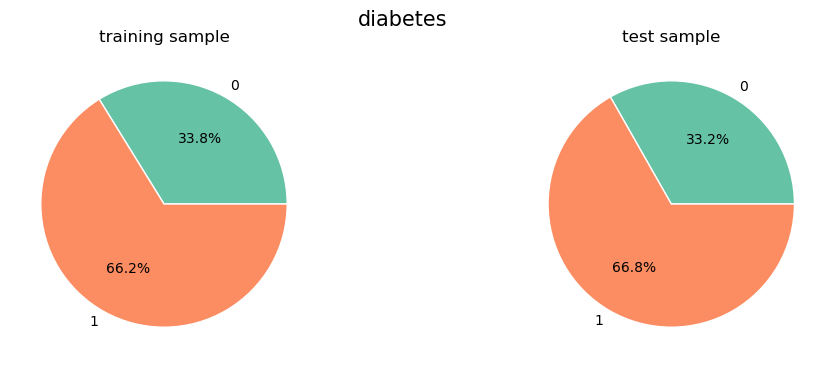

In [33]:
pie_chart('diabetes')

Пациентов с диабетом примерно в два раза больше и в тестовой, и в тренировочной выборках

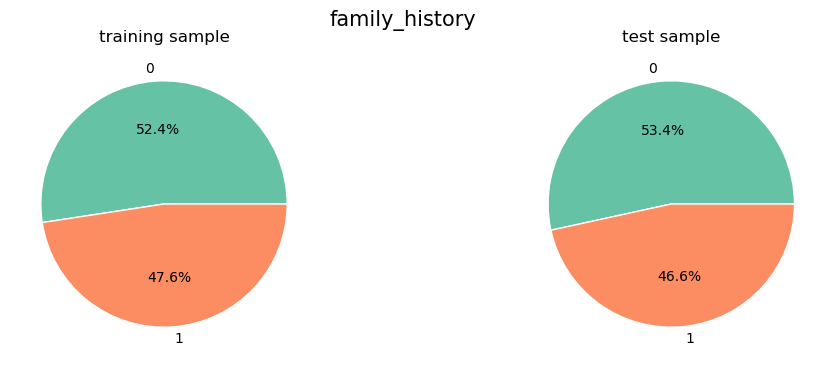

In [34]:
pie_chart('family_history')

Пациентов с наследственными заболеваниями и  без них примерно одинаково в каждой выборке

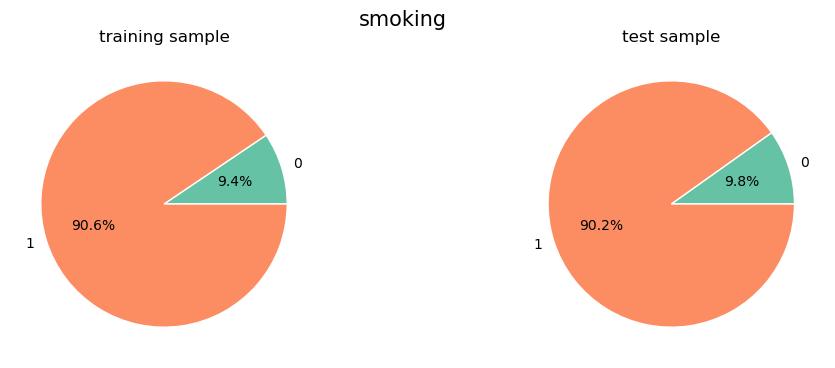

In [35]:
pie_chart('smoking')

В обеих выборках курящих около 90 процентов, а некурящих людей менее 10 процентов

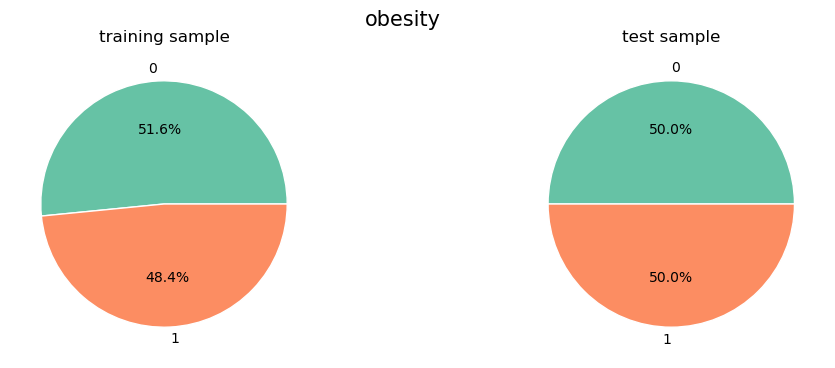

In [36]:
pie_chart('obesity')

Среди пациентов примерно равное количество людей с ожирением и без 

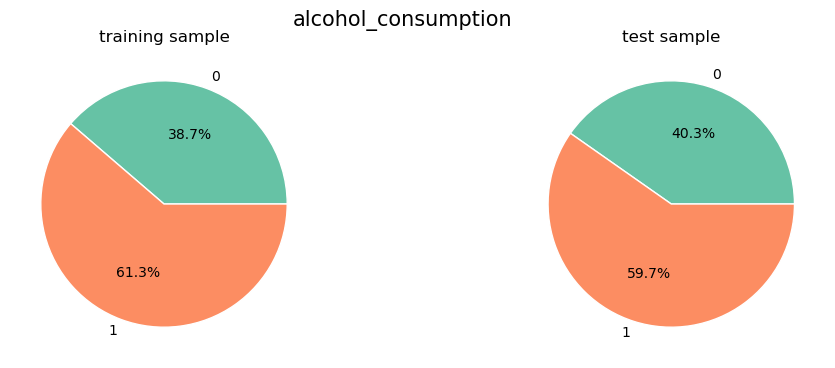

In [37]:
pie_chart('alcohol_consumption')

Около 60 процентов опрашиваемых употребляют алкоголь 

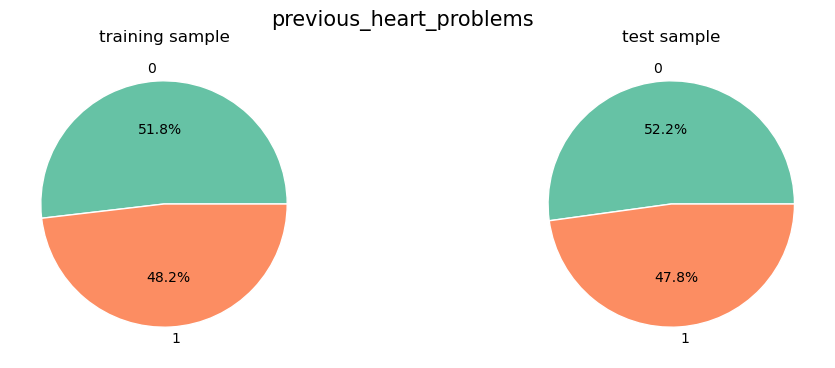

In [38]:
pie_chart('previous_heart_problems')

Ранее имели проблемы с сердцем около половины пациентов 

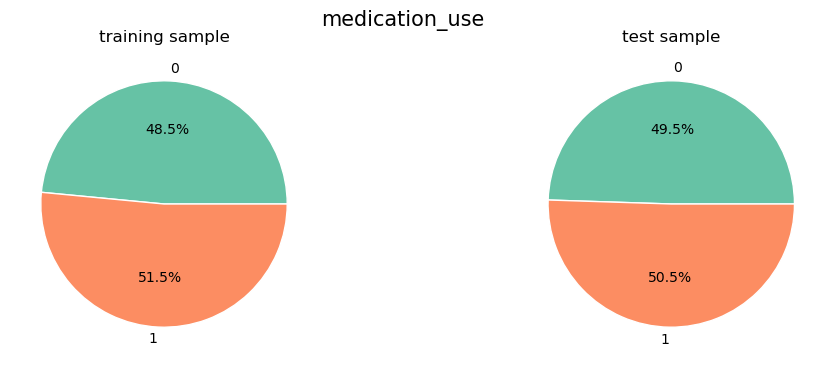

In [39]:
pie_chart('medication_use')

Половина пациентов употребляют лекарства

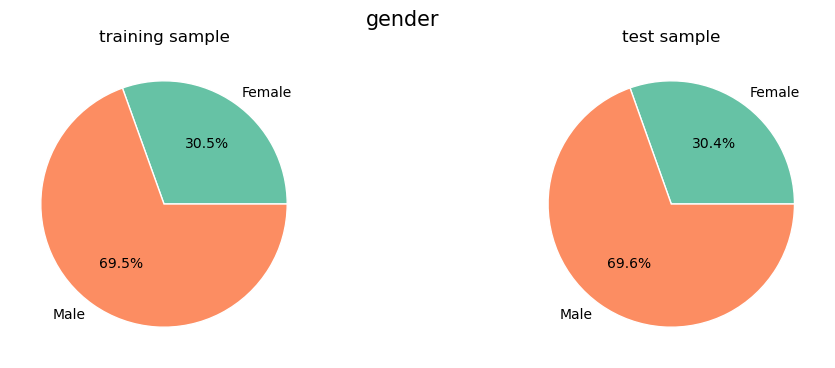

In [40]:
pie_chart('gender')

В обеих выборках подавляющее число пациентов - мужчины, их около 70 процентов. Около 30 процентов - женщин. 

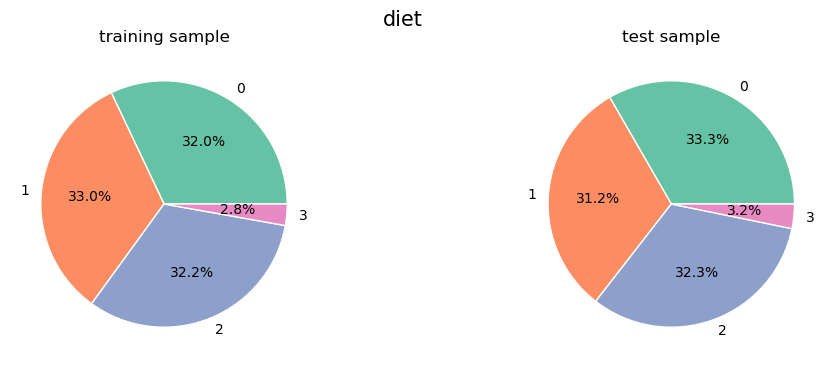

In [41]:
pie_chart('diet')

Распределения для тренировочной и тестовой выборок одинаковые: примерно равное количество пациентов имеют **0**, **1**, **2**, и лишь малая доля имеет диету **3**. 

### Дискретные количественные признаки

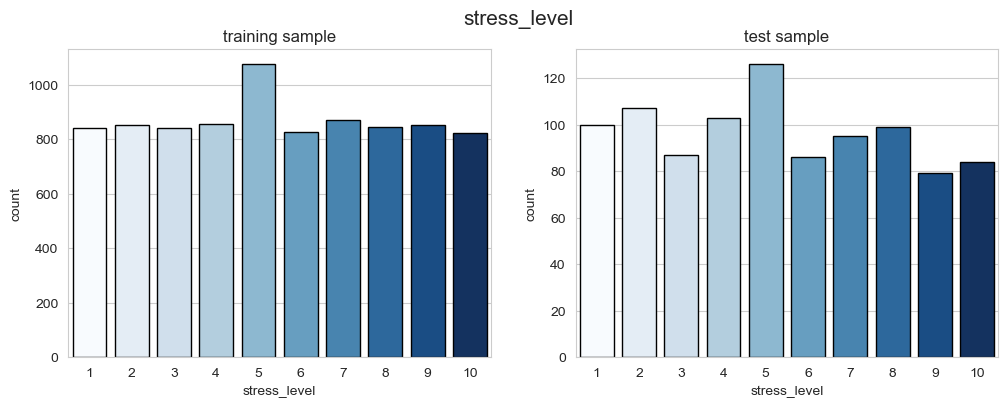

In [42]:
countplot('stress_level')

В обеих выборках примерно одинаковое количество людей имеют разный уровень стресса (от 0 до 10), а у большинства пациентов уровень стресса **5**.  

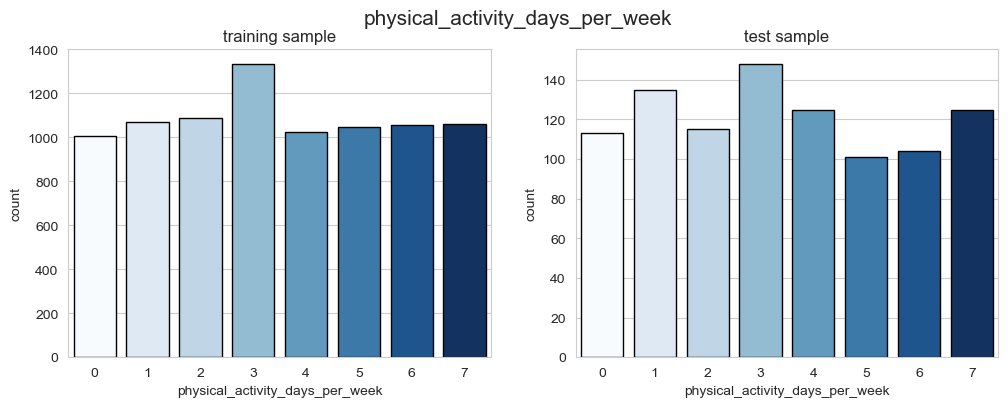

In [43]:
countplot('physical_activity_days_per_week')

В обеих выборках примерно одинаковое количество людей имеют разное дней физической активности в неделю (от 0 до 7).  

### Непрерывные количественные признаки

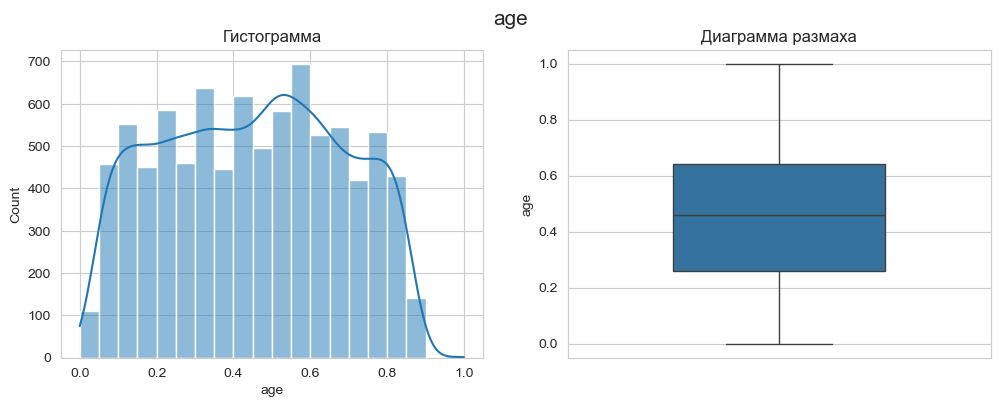

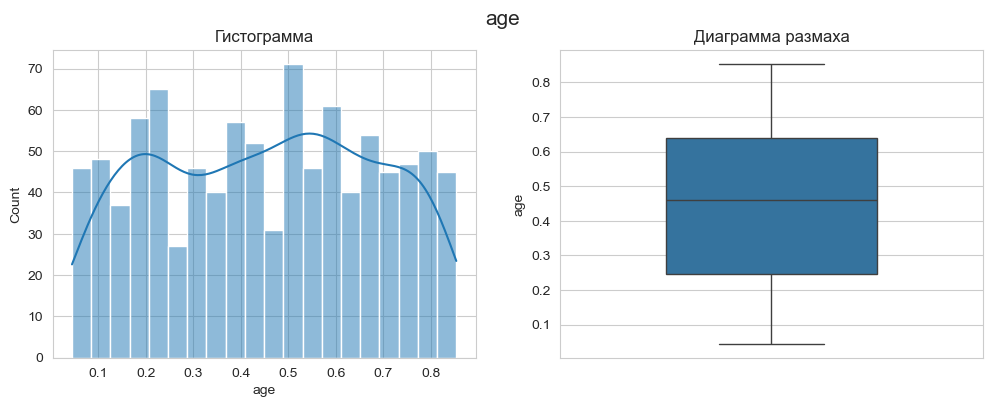

In [44]:
hist_and_boxplot('age', df_train)
hist_and_boxplot('age', df_test)

Значения возраста масштабированы. Выбросов и аномальных значений нет. 

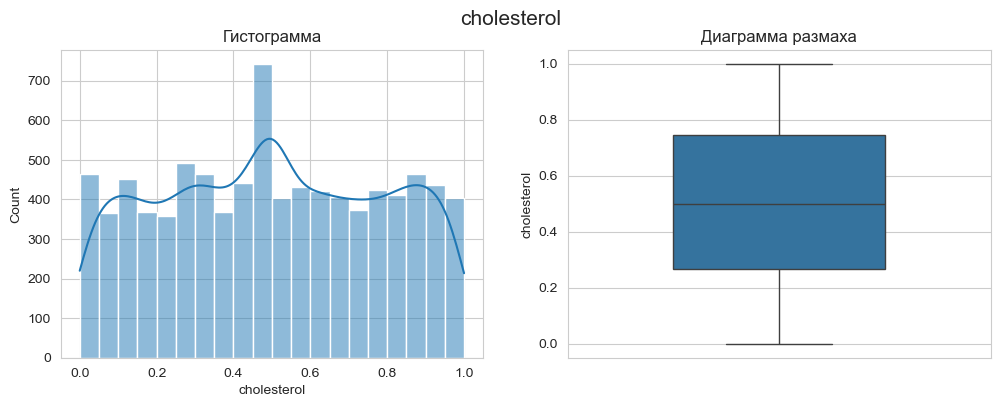

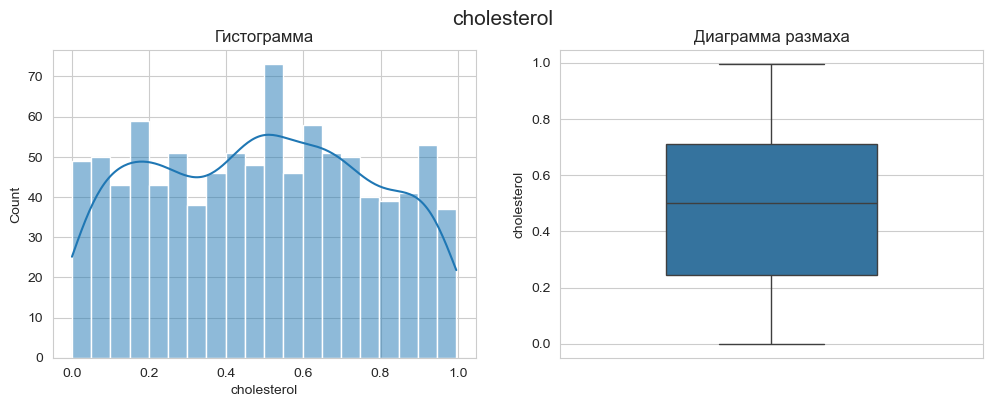

In [45]:
hist_and_boxplot('cholesterol', df_train)
hist_and_boxplot('cholesterol', df_test)

Значения уровня холестерина тоже масштабированы. Наибольшее число пациентов имеют уровень холестерина около 0,5.

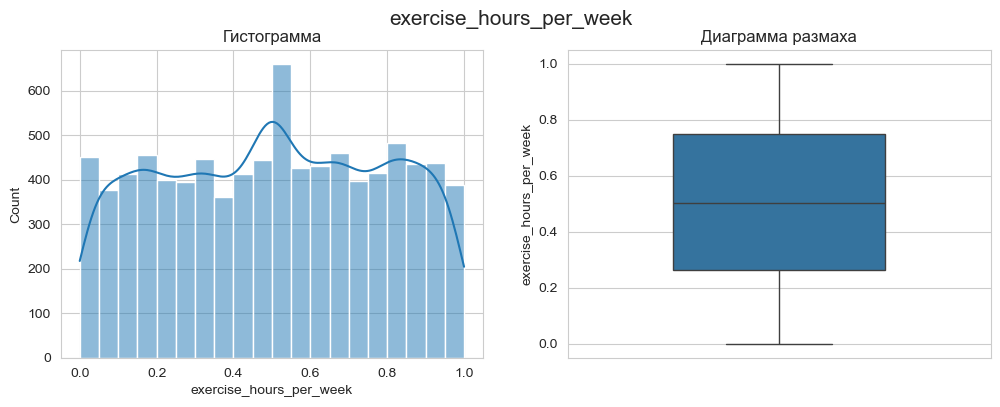

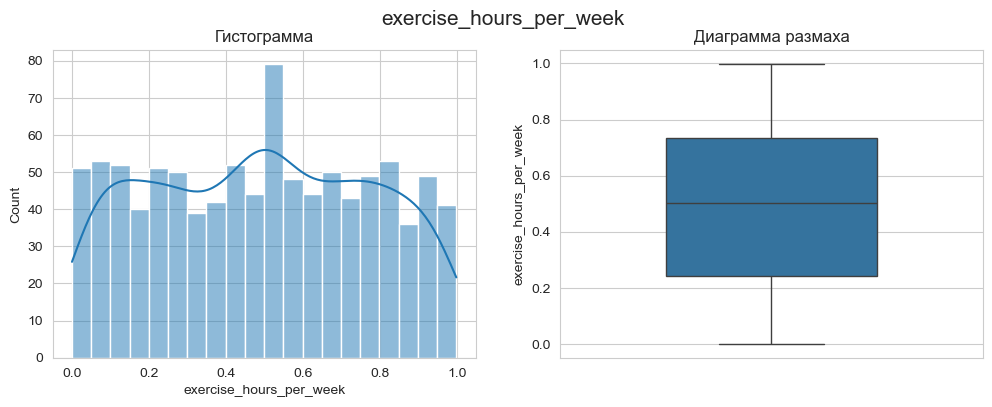

In [46]:
hist_and_boxplot('exercise_hours_per_week', df_train)
hist_and_boxplot('exercise_hours_per_week', df_test)

Распределение пациентов с разным количеством часов упражнений в неделю (с учетом маштабирования) примерно равномерное, однако наблюдается пик у значения 0,5.

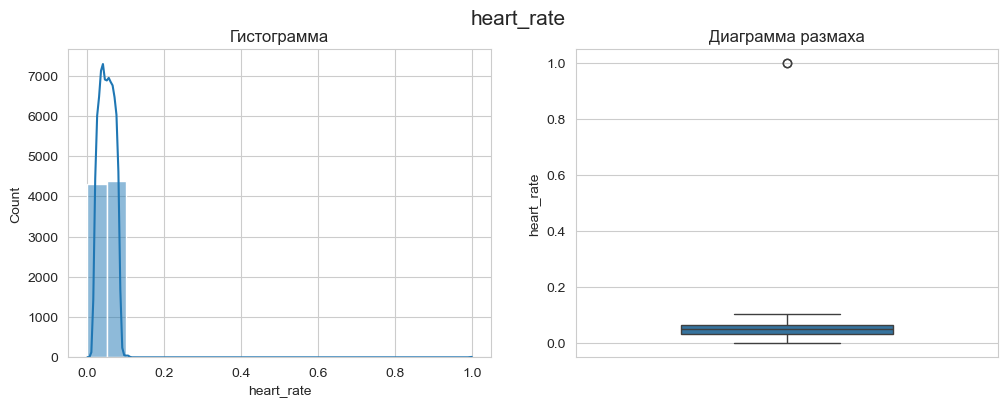

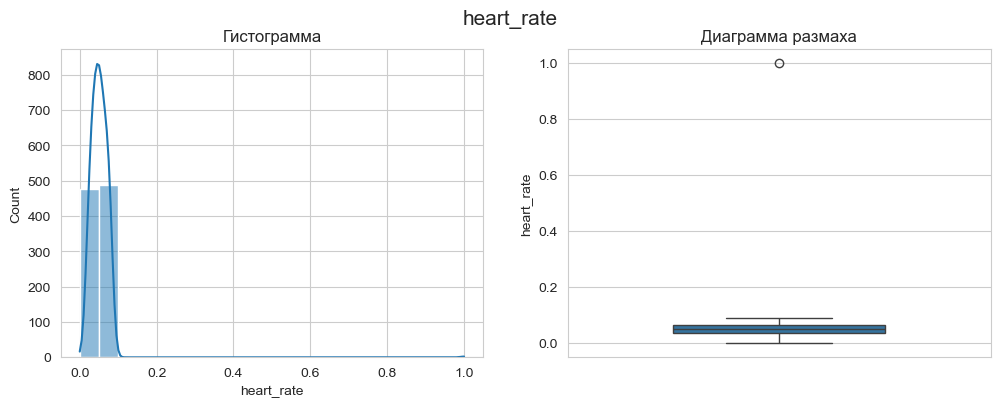

In [47]:
hist_and_boxplot('heart_rate', df_train)
hist_and_boxplot('heart_rate', df_test)

На диаграммах размаха видно, что у признака **heart_rate** есть выбросы. Изучим их подробнее

In [48]:
df_train[df_train['heart_rate'] > 0.2]

,age,cholesterol,heart_rate,diabetes,family_history,smoking,obesity,alcohol_consumption,exercise_hours_per_week,diet,previous_heart_problems,medication_use,stress_level,sedentary_hours_per_day,bmi,triglycerides,physical_activity_days_per_week,sleep_hours_per_day,heart_attack_risk,blood_sugar,gender,systolic_blood_pressure,diastolic_blood_pressure,id
1377,0.629213,0.49978,1.0,1,0,1,0,1,0.50211,3,0,1,5,0.49992,0.494774,0.503603,3,0.504621,0,0.203557,Female,0.490323,0.616279,9547
2712,0.202247,0.49978,1.0,1,0,1,0,1,0.50211,3,0,1,5,0.49992,0.494774,0.503603,3,0.504621,0,0.092885,Female,0.490323,0.616279,9611


In [49]:
df_test[df_test['heart_rate'] > 0.2]

,age,cholesterol,heart_rate,diabetes,family_history,smoking,obesity,alcohol_consumption,exercise_hours_per_week,diet,previous_heart_problems,medication_use,stress_level,sedentary_hours_per_day,bmi,triglycerides,physical_activity_days_per_week,sleep_hours_per_day,blood_sugar,gender,systolic_blood_pressure,diastolic_blood_pressure,id
456,0.348315,0.49978,1.0,1,0,1,0,1,0.50211,3,0,1,5,0.49992,0.494774,0.503603,3,0.504621,0.146245,Male,0.490323,0.616279,9394


У двух пациентов в тренировочной выборке и у одного в тестовой частота сердцебиения 1, при том что у остальных она варьируется в диапазоне от 0 до 0.1. Скорее всего здесь была допущена ошибка, т.к. не может быть пульса в 5 раз превыщающего среднее значение. Поэтому заменим выбросы средним значением. 

In [50]:
df_train.loc[df_train['heart_rate'] > 0.2, 'heart_rate'] = df_train['heart_rate'].mean()
df_test.loc[df_test['heart_rate'] > 0.2, 'heart_rate'] = df_train['heart_rate'].mean()

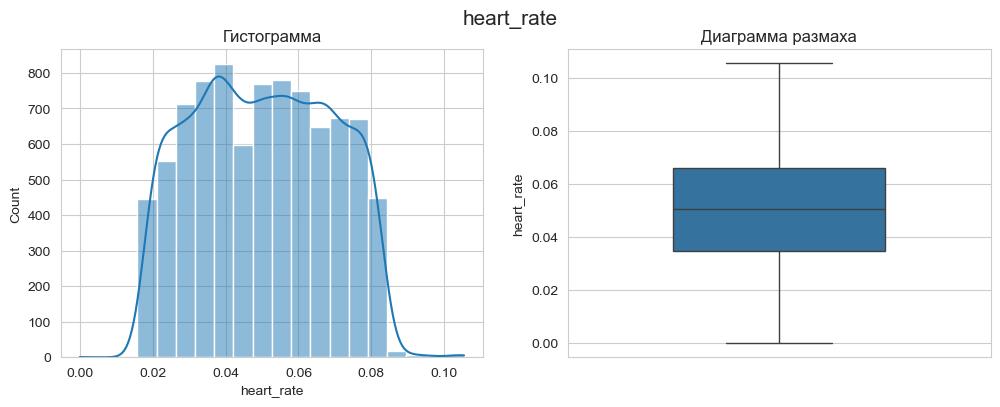

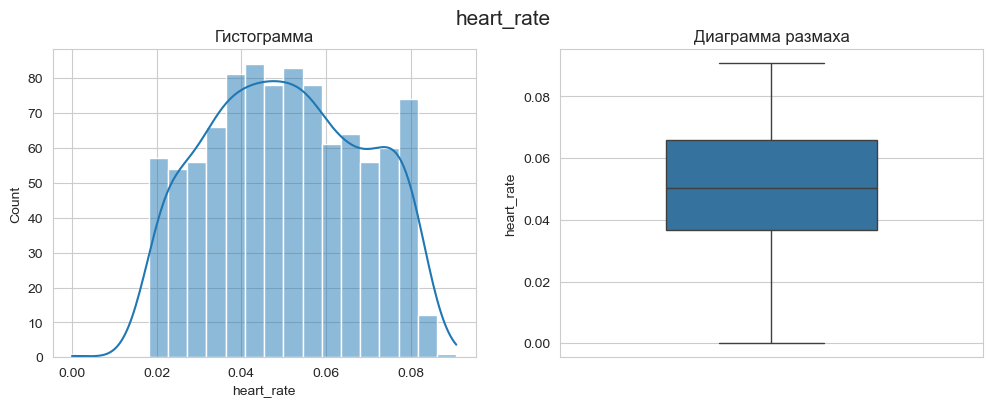

In [51]:
hist_and_boxplot('heart_rate', df_train)
hist_and_boxplot('heart_rate', df_test)

Избавились от выбросов. Частота варьируется примерно от 0.02 до 0.08.

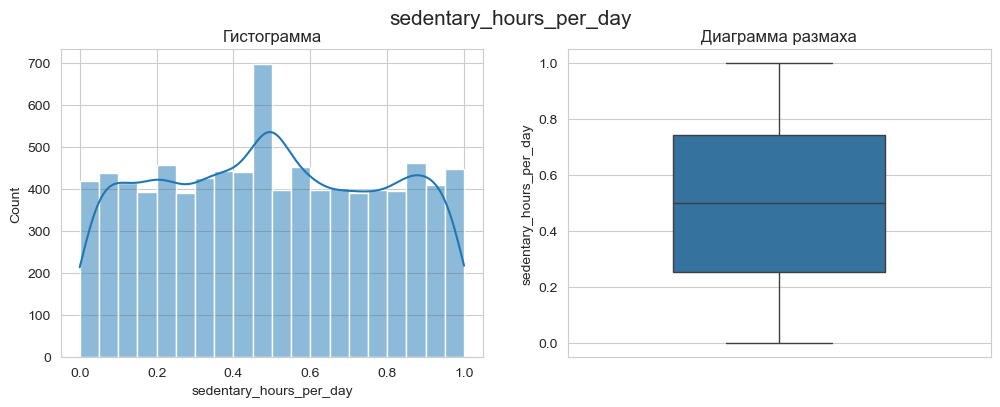

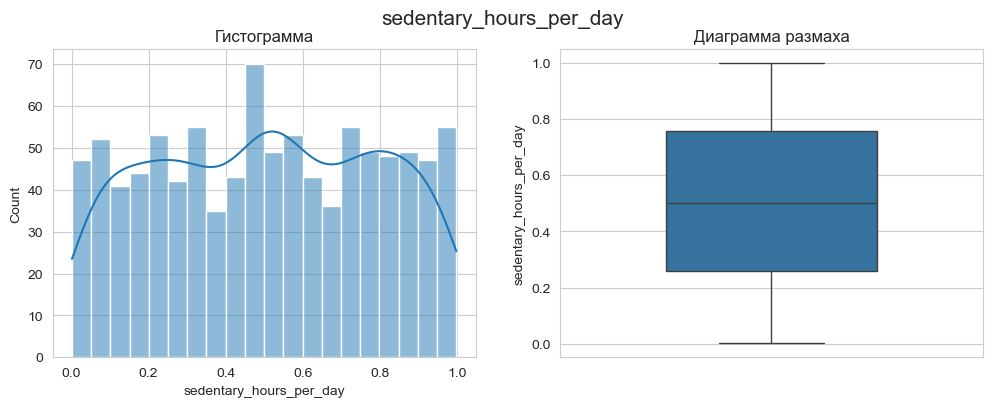

In [52]:
hist_and_boxplot('sedentary_hours_per_day', df_train)
hist_and_boxplot('sedentary_hours_per_day', df_test)

Распределение часов сидячего образа жизни в день аналогично распределению пациентов с разным количеством часов упражнений в неделю.

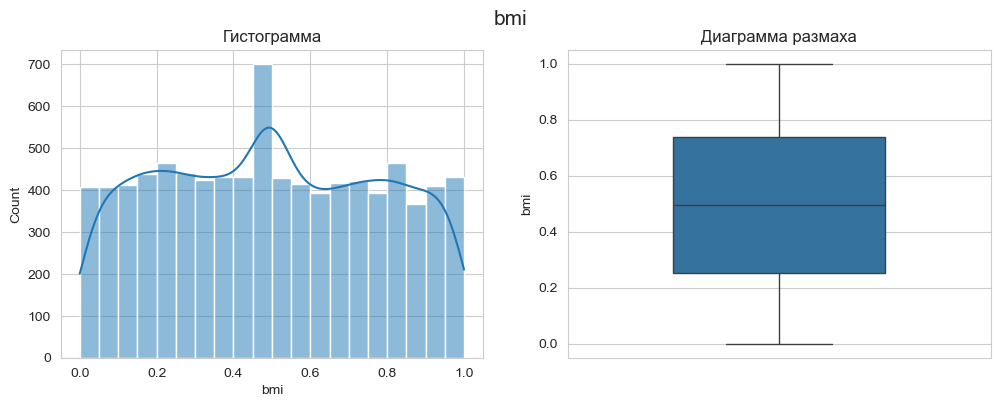

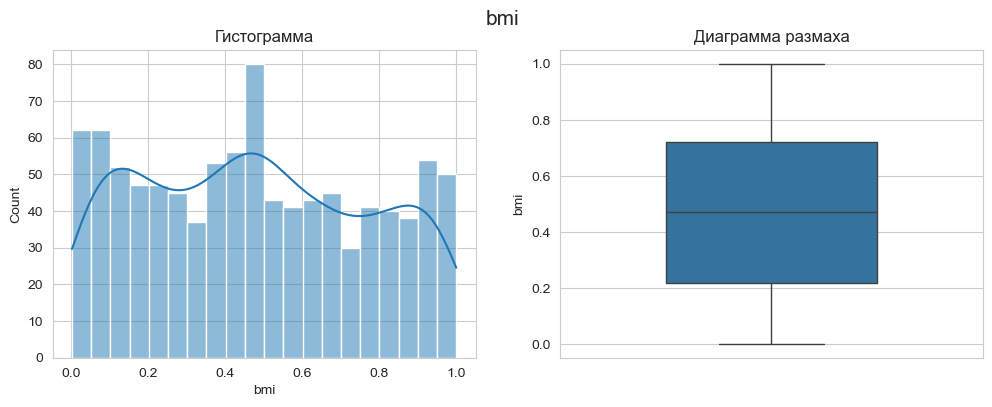

In [53]:
hist_and_boxplot('bmi', df_train)
hist_and_boxplot('bmi', df_test)

Для обоих выборок у распределений индекса массы тела заметен значительный пик около 0.5.  

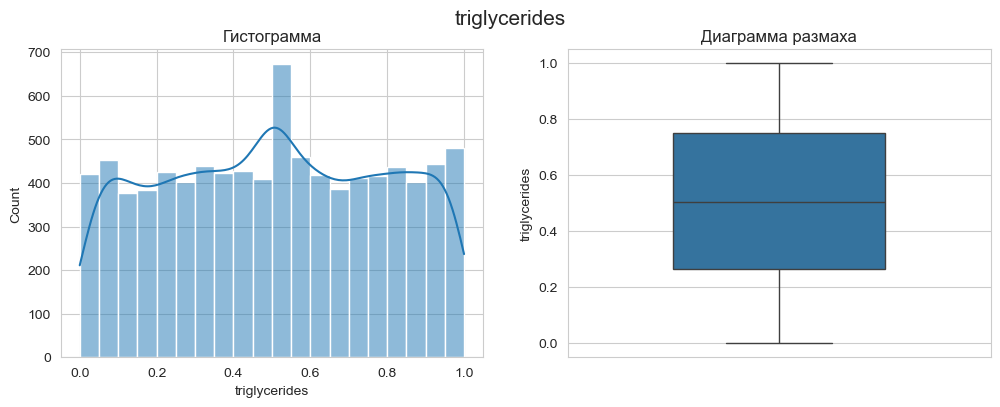

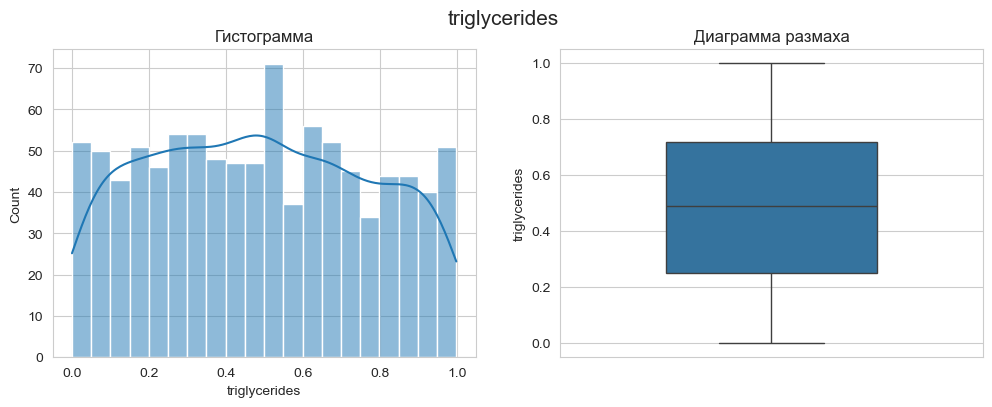

In [54]:
hist_and_boxplot('triglycerides', df_train)
hist_and_boxplot('triglycerides', df_test)

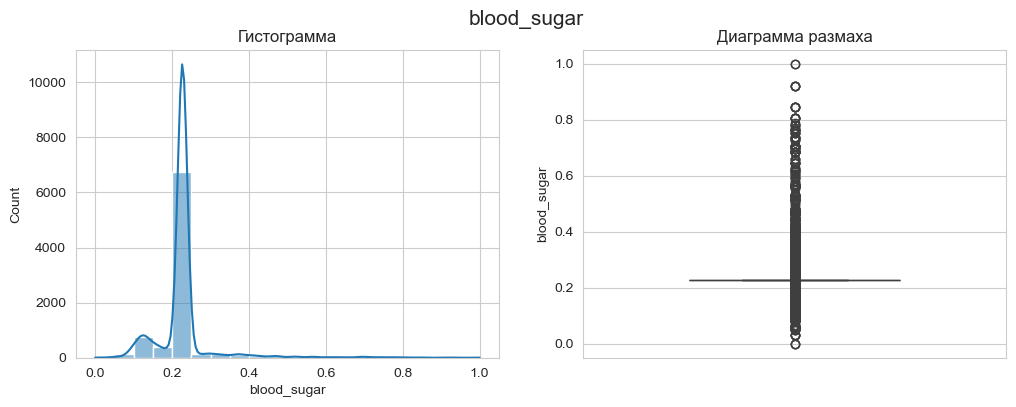

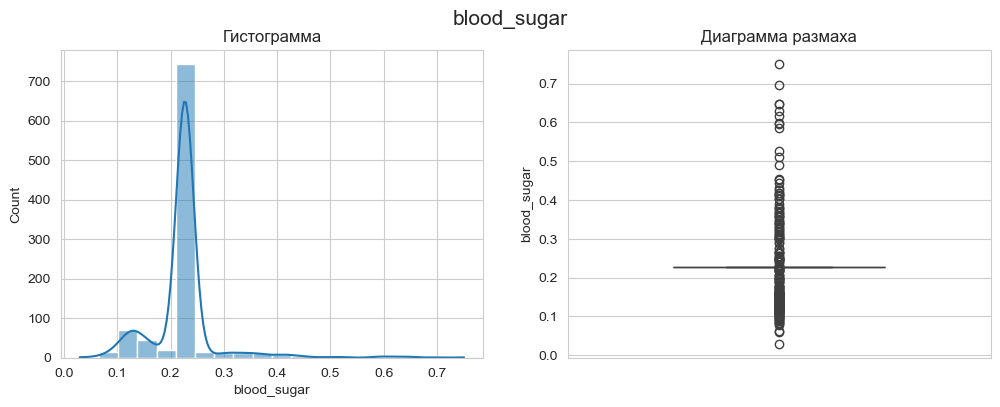

In [55]:
hist_and_boxplot('blood_sugar', df_train)
hist_and_boxplot('blood_sugar', df_test)

Значения сахара в крови варьируется в тренировочной выборке от 0 до 1, а в тестовой выборке до 0.7 единиц. Это может быть связано просто с разным количеством данных в выборках. Однако распределения похожи и среднее значение в обоих выборках сахара в крови около 0.2 единиц.

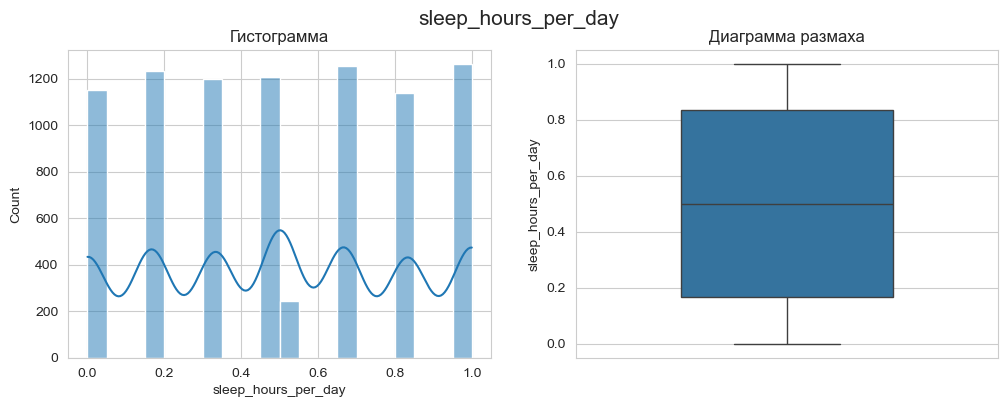

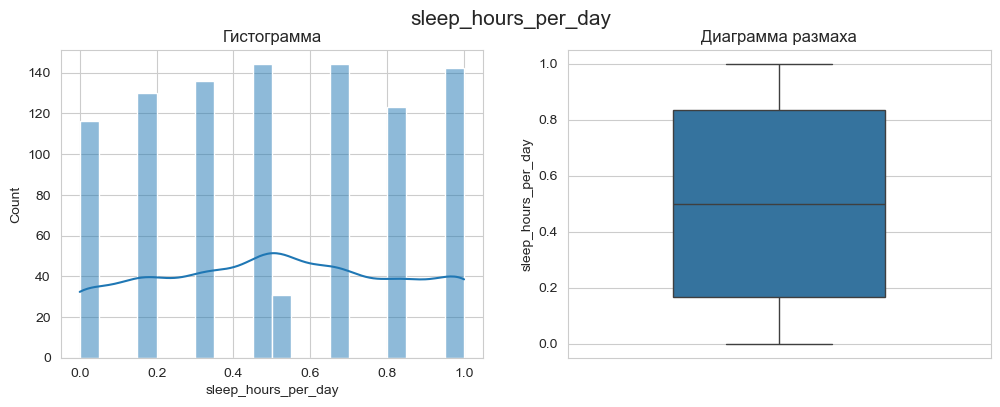

In [56]:
hist_and_boxplot('sleep_hours_per_day', df_train)
hist_and_boxplot('sleep_hours_per_day', df_test)

Количество часов сна в сутки тоже было масштабировано и хотя в таблице данные принимали вещественные значения, то распределение имеет преимущественно дискретный характер. При этом распределения в обеих выборках демонстрируют сходство.

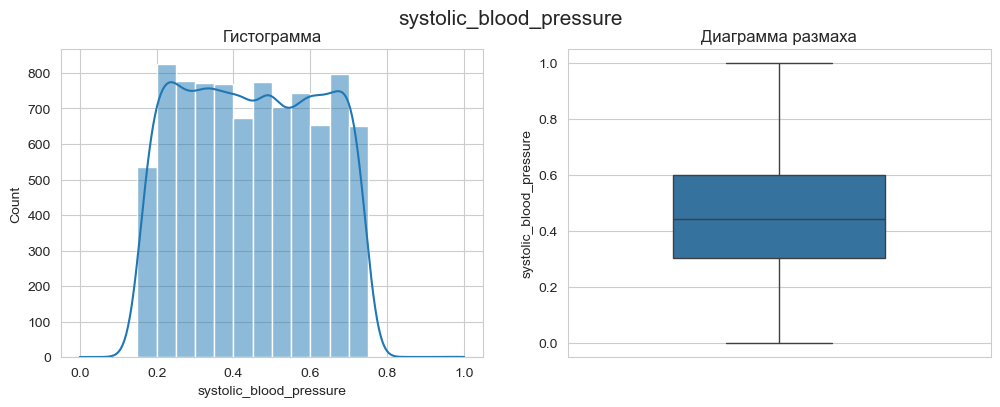

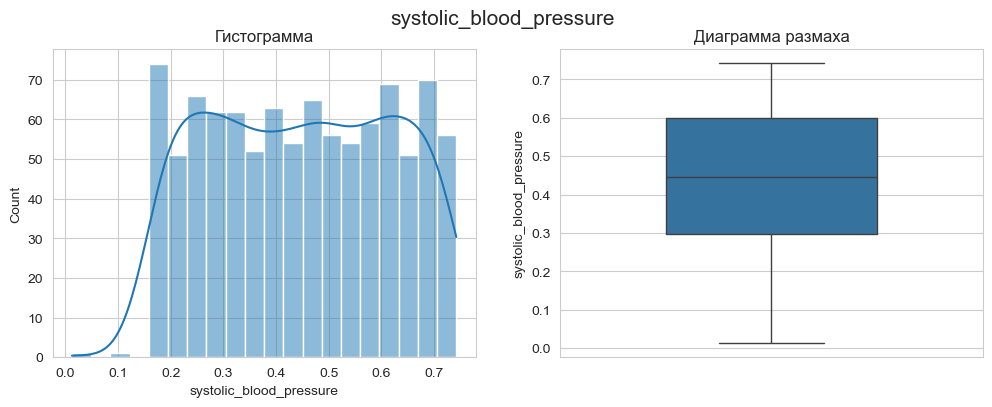

In [57]:
hist_and_boxplot('systolic_blood_pressure', df_train)
hist_and_boxplot('systolic_blood_pressure', df_test)

В тренировочной выборке систолическое давление варьируются в диапазоне от 0 до 1 единицы, тогда как в тестовой выборке максимальный уровень составляет 0,7. Такая разница может объясняться неодинаковым объёмом данных в двух выборках. При этом характер распределений в обеих выборках схож, а средние значения приблизительно равны 0,4 единицы.

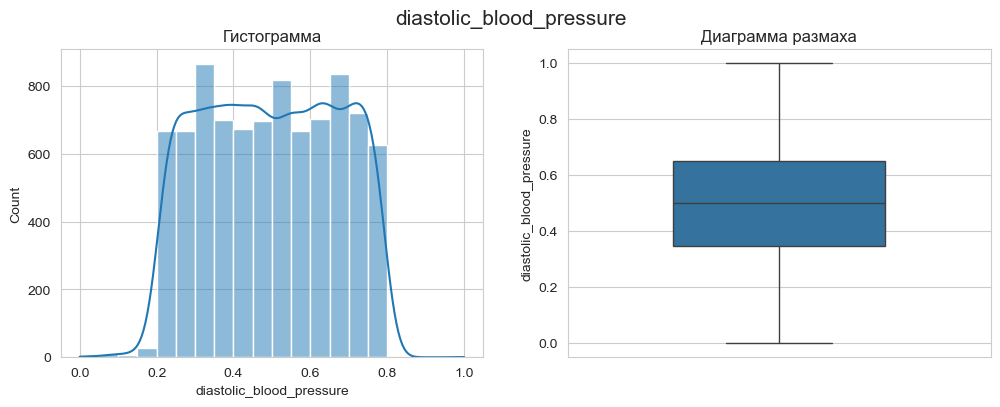

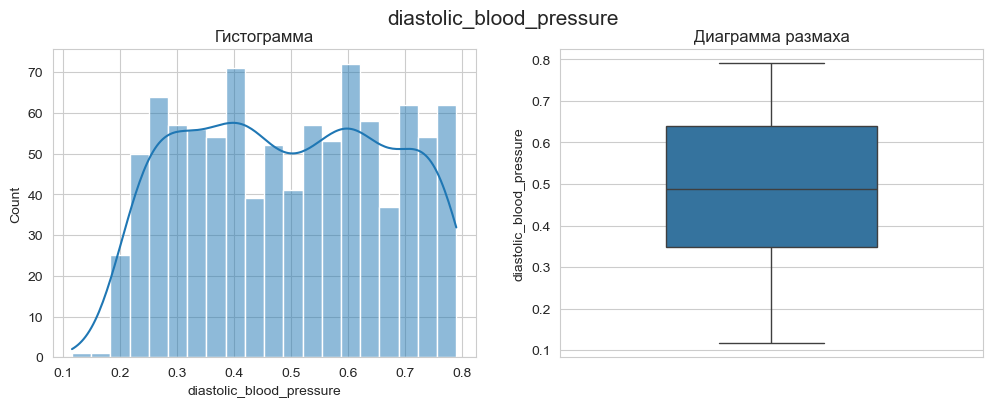

In [58]:
hist_and_boxplot('diastolic_blood_pressure', df_train)
hist_and_boxplot('diastolic_blood_pressure', df_test)

Распределения диастолического кровяного давления схожи с распределениями систолическими кровяного давления. Заметим, что среднее значение диастолического давления оказалось выше систолического, хотя систолического давление (верхний показатель) должно быть больше диастолического(нижний показатель). Но значения были отмасштабированы поэтому оценивать нужно каждый признак по отдельности.

**Выводы:**  Для всех признаков распределения данных тренировочной и тестовой выборки похожи. Это важно для построения эффективной модели прогнозирования. 

Также были обнаружены выбросы для **heart_rate** в обеих выборках, от них мы избавились для обеспечения качества моделирования.

## Корреляционный анализ данных

Построим матрицу корреляции

In [59]:
interval_cols= df_train[['age', 'cholesterol', 'heart_rate', 'exercise_hours_per_week',\
                     'sedentary_hours_per_day', 'bmi', 'triglycerides', 'blood_sugar', 'systolic_blood_pressure', 'diastolic_blood_pressure']]

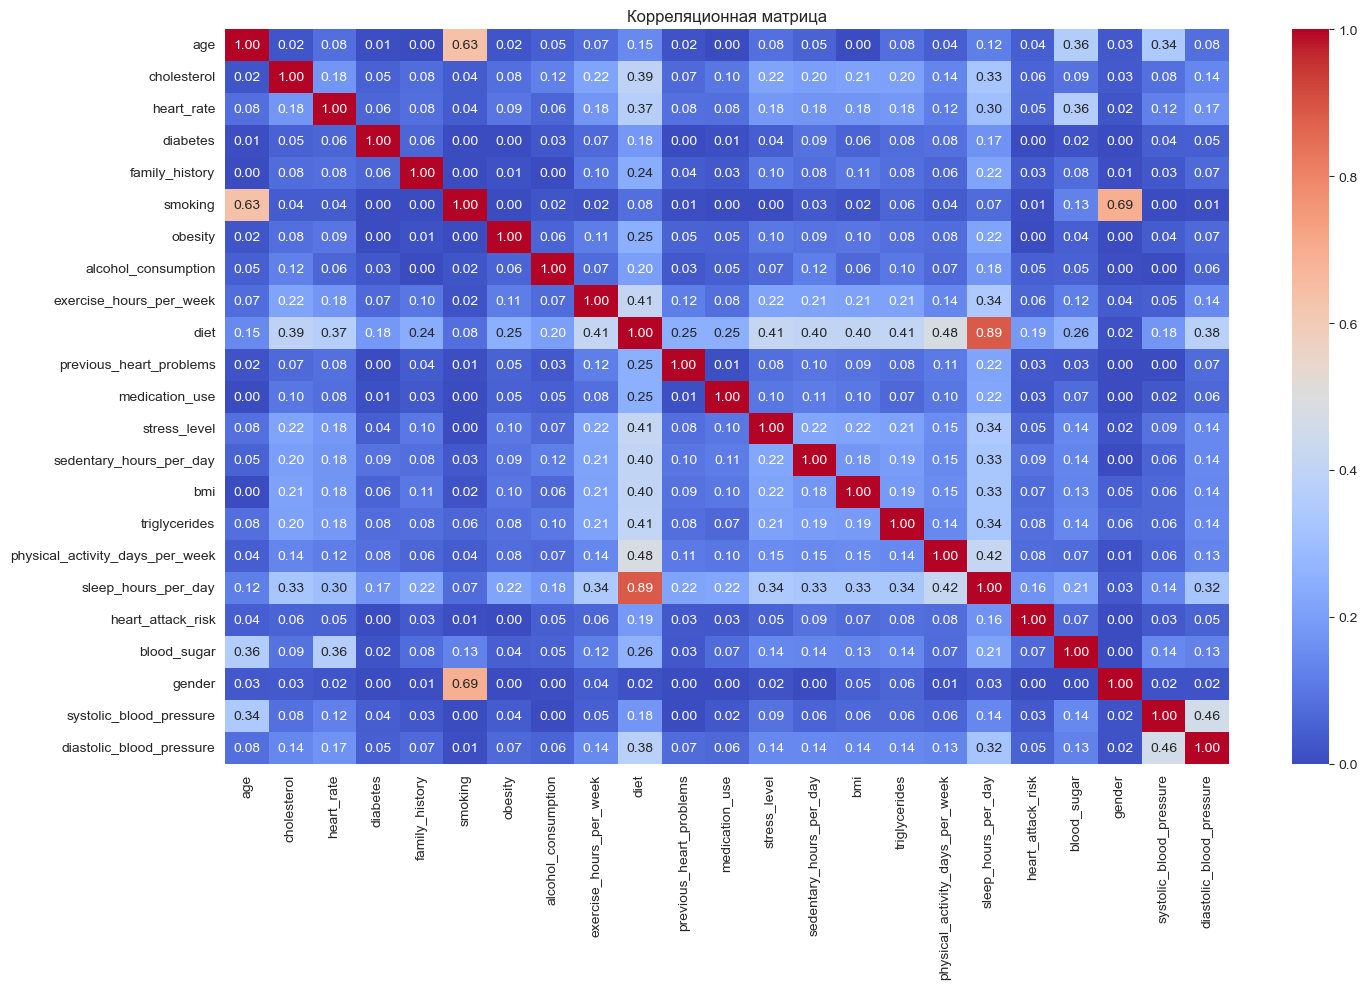

In [60]:
phik_matrix = df_train.drop('id', axis=1).phik_matrix(interval_cols=interval_cols)
plt.figure(figsize=(15, 10))
sns.heatmap(phik_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.tight_layout()
plt.show()

Целевой признак **heart_attack_risk** с входными признаками почти не коррелирует. У входных признаков наибольшая корреляция наблюдается между признаками "sleep_hours_per_day" и "diet", а также сильная корреляция есть между признаками "smoking" и "age", "smoking" и "gender".

Аналогично проведем анализ корреляции для тестовой выборки.

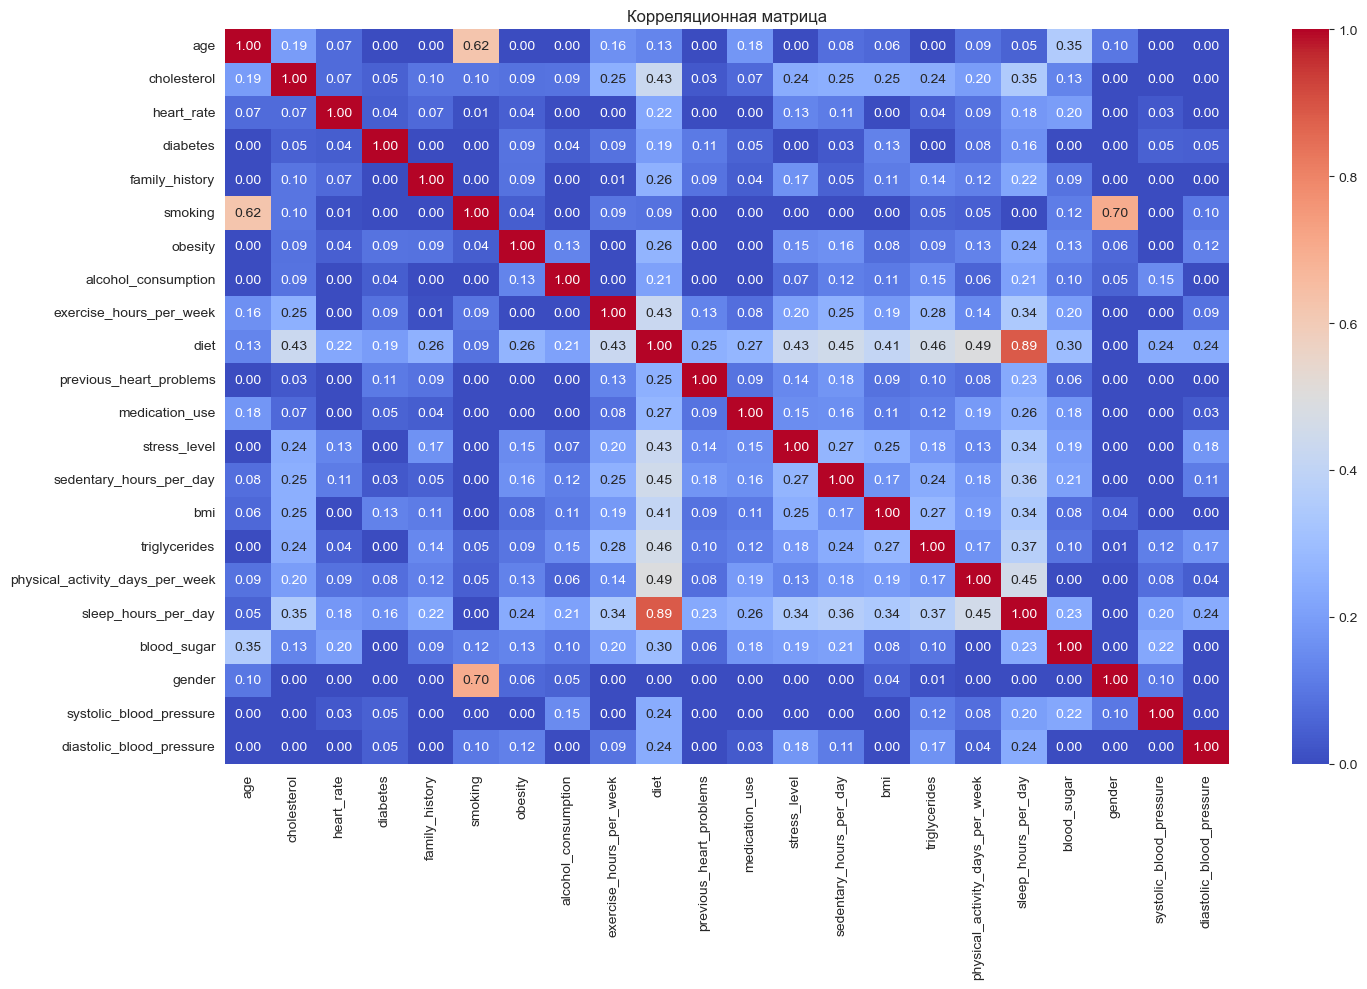

In [61]:
interval_cols= df_test[['age', 'cholesterol', 'heart_rate', 'exercise_hours_per_week',\
                     'sedentary_hours_per_day', 'bmi', 'triglycerides', 'blood_sugar', 'systolic_blood_pressure', 'diastolic_blood_pressure']]
phik_matrix = df_test.drop('id', axis=1).phik_matrix(interval_cols=interval_cols)
plt.figure(figsize=(15, 10))
sns.heatmap(phik_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.tight_layout()
plt.show()

Видно, что для тренировочной выборки корреляционная матрица почти не отличается от матрицы тренировочной выборки. Связь между признаками аналогичная.

**Выводы:**
* У входных признаков наибольшая корреляция наблюдается между признаками "sleep_hours_per_day" и "diet"
* Сильная корреляция наблюдается между признаками "smoking" и "age", "smoking" и "gender".
* У целевого признака корреляция с остальными признаками корелляция очень слабая

## Использование пайплайнов для нахождения лучшей модели

In [62]:
data = df_train.copy()

Проверим тренировочную выборку на баланс классов

In [63]:
print(f'Пациентов без риска сердечного приступа - {len(data[data['heart_attack_risk'] == 0])}')
print(f'Пациентов c риском сердечного приступа - {len(data[data['heart_attack_risk'] == 1])}')

Пациентов без риска сердечного приступа - 5672
Пациентов c риском сердечного приступа - 3013


Пациентов с риском сердечного приступа значительно меньше. Для дальнейшего удобства работы с данными установим колонку id в качестве индекса датафрейма. 

In [64]:
# устанавливаем столбец 'id' в качестве индекса
data = data.set_index('id')
data.head()

,age,cholesterol,heart_rate,diabetes,family_history,smoking,obesity,alcohol_consumption,exercise_hours_per_week,diet,previous_heart_problems,medication_use,stress_level,sedentary_hours_per_day,bmi,triglycerides,physical_activity_days_per_week,sleep_hours_per_day,heart_attack_risk,blood_sugar,gender,systolic_blood_pressure,diastolic_blood_pressure
id,,,,,,,,,,,,,,,,,,,,,,,
2664,0.359551,0.732143,0.074244,1,1,1,1,1,0.535505,1,1,0,8,0.225704,0.459176,0.979221,3,0.333333,0,0.227018,Male,0.212903,0.709302
9287,0.202247,0.325000,0.047663,1,1,0,0,1,0.068690,2,1,0,9,0.289923,0.117053,0.515584,3,0.833333,0,0.150198,Female,0.412903,0.569767
5379,0.606742,0.860714,0.055912,1,0,1,1,1,0.944001,2,1,1,6,0.550133,0.373574,0.012987,2,1.000000,0,0.227018,Female,0.238710,0.220930
8222,0.730337,0.007143,0.053162,0,0,1,0,1,0.697023,0,0,1,3,0.330962,0.049735,0.131169,0,0.333333,1,0.227018,Female,0.348387,0.267442
4047,0.775281,0.757143,0.021998,0,0,1,0,1,0.412878,1,0,0,8,0.524600,0.830405,0.070130,5,1.000000,1,0.227018,Male,0.619355,0.441860


Проверим данные на наличие новых дубликатов.

In [65]:
print(f'В тренировочной выборке {data.duplicated().sum()} дубликатов') 

В тренировочной выборке 12 дубликатов


В данных появились явные дубликаты, но их немного, поэтому удалим дубликаты.

In [66]:
data = data.drop_duplicates(keep='first')
print(f'В тренировочной выборке стало {data.duplicated().sum()} дубликатов') 
print(f'Длина датафрейма после удаления части данных стала {len(data)}')

В тренировочной выборке стало 0 дубликатов
Длина датафрейма после удаления части данных стала 8673


Создадим пайплайн для подготовки данных

In [67]:
RANDOM_STATE = 42

# определяем целевой и входные признаки
X_train, X_valid, y_train, y_valid = train_test_split(
    data.drop(['heart_attack_risk'], axis=1),
    data['heart_attack_risk'],
    test_size = 0.25, 
    random_state = RANDOM_STATE,
    stratify = data['heart_attack_risk'])

In [68]:
# создаём списки с названиями признаков
ohe_columns = ['gender']
ord_columns = ['diabetes', 'family_history', 'smoking', 'obesity', 'alcohol_consumption', 'previous_heart_problems', 'medication_use', 'diet']
num_columns = ['stress_level', 'physical_activity_days_per_week']

In [69]:
# создаём пайплайн для подготовки признаков из списка ohe_columns: заполнение пропусков и OHE-кодирование
# SimpleImputer + OHE
ohe_pipe = Pipeline(
    [
        ('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
    ]
)

In [70]:
# создаём пайплайн для подготовки признаков из списка ord_columns: заполнение пропусков и Ordinal-кодирование
# SimpleImputer + OE
ord_pipe = Pipeline(
    [
        (
            'simple_imputer_ord_before',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ord',
            OrdinalEncoder(
                          handle_unknown='use_encoded_value',
                          unknown_value=np.nan)
        ),
        (
            'simple_imputer_ord_after',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

In [71]:
# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

In [72]:
# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

In [73]:
param_grid = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 10),
        'models__max_features': range(2, 10),
        'models__min_samples_split': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    
    # словарь для модели KNeighborsClassifier() 
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },

    # словарь для модели RandomForestClassifier()
    {
    'models': [RandomForestClassifier(random_state=RANDOM_STATE)],
    'models__n_estimators': [50, 100, 200],
    'models__max_depth': [None, 10, 20, 30],
    'models__min_samples_split': [2, 5, 10],
    'models__min_samples_leaf': [1, 2, 4],
    'models__max_features': ['sqrt', 'log2', None],
    'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
},
   #словарь для модели CatBoost
    {
    'models__iterations': [100, 200],       
    'models__depth': [4, 6],                   
    'models__learning_rate': [0.03, 0.1], 
    'models__l2_leaf_reg': [1, 3],           
    'models__border_count': [32, 64],       
    'models__bagging_temperature': [0, 1],  
    'models__random_strength': [0, 1]
    }
]

In [74]:
# запускаем автоматический подбор 
randomized_search = RandomizedSearchCV(
    pipe_final,
    param_grid,
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

Для оценки качества моделей выбрана метрика ROC-AUC, которая подходит для бинарной классификации с несбалансированной выборкой. В нашем случае пациентов с риском сердечного приступа значительно меньше, чем пациентов без такого риска.

In [75]:
randomized_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'models': [DecisionTreeC...ndom_state=42)], 'models__max_depth': range(2, 10), 'models__max_features': range(2, 10), 'models__min_samples_split': range(2, 10), ...}, {'models': [KNeighborsClassifier()], 'models__n_neighbors': range(2, 10), 'preprocessor__num': [StandardScaler(), MinMaxScaler(), ...]}, ...]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These spl

In [76]:
print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print ('Метрика по тренировочной выборке:', round(randomized_search.best_score_, 2))

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender']),
                                                 ('ord',
                                                  Pipeline(steps=[('simple_imputer_ord_before',
                        

In [77]:
y_valid_pred = randomized_search.predict_proba(X_valid)[:, 1]
print(f'Метрика на валидационной выборке: {round(roc_auc_score(y_valid, y_valid_pred), 2)}')

Метрика на валидационной выборке: 0.58


**Вывод:**
На данном этапе было выполнено обучение нескольких моделей посредством конвейера.
* Были обработаны отдельно количественные и категориальные признаки 
* Обучены 4 модели: **KNeighborsClassifier**, **DecisionTreeClassifier**, **RandomForestClassifier**, **CatBoost** 
* Для подбора гиперпараметров использовался рандомизированный поиск для более быстрого поиска
* Для оценки качества моделей выбрана метрика ROC-AUC, которая подходит для бинарной классификации с несбалансированной выборкой
* В результате метрика ROC-AUC достигла 0.59 на тренировочной выборке для модели **RandomForestClassifier**,
это не очень высокий показатель качества модели 

## Анализ важности признаков

Оценим важность признаков для лучшей модели и построим график важности с помощью метода SHAP

In [78]:
# лучшая найденная модель
best_model = randomized_search.best_estimator_.named_steps['models']
preprocessor = randomized_search.best_estimator_.named_steps['preprocessor']
# предобработка 
X_train_processed = preprocessor.transform(X_train)
feature_names = preprocessor.get_feature_names_out()
explainer = shap.Explainer(best_model.predict_proba, X_train_processed, feature_names=feature_names) 
shap_values = explainer(X_train_processed)

PermutationExplainer explainer: 6505it [1:30:36,  1.19it/s]                                                            


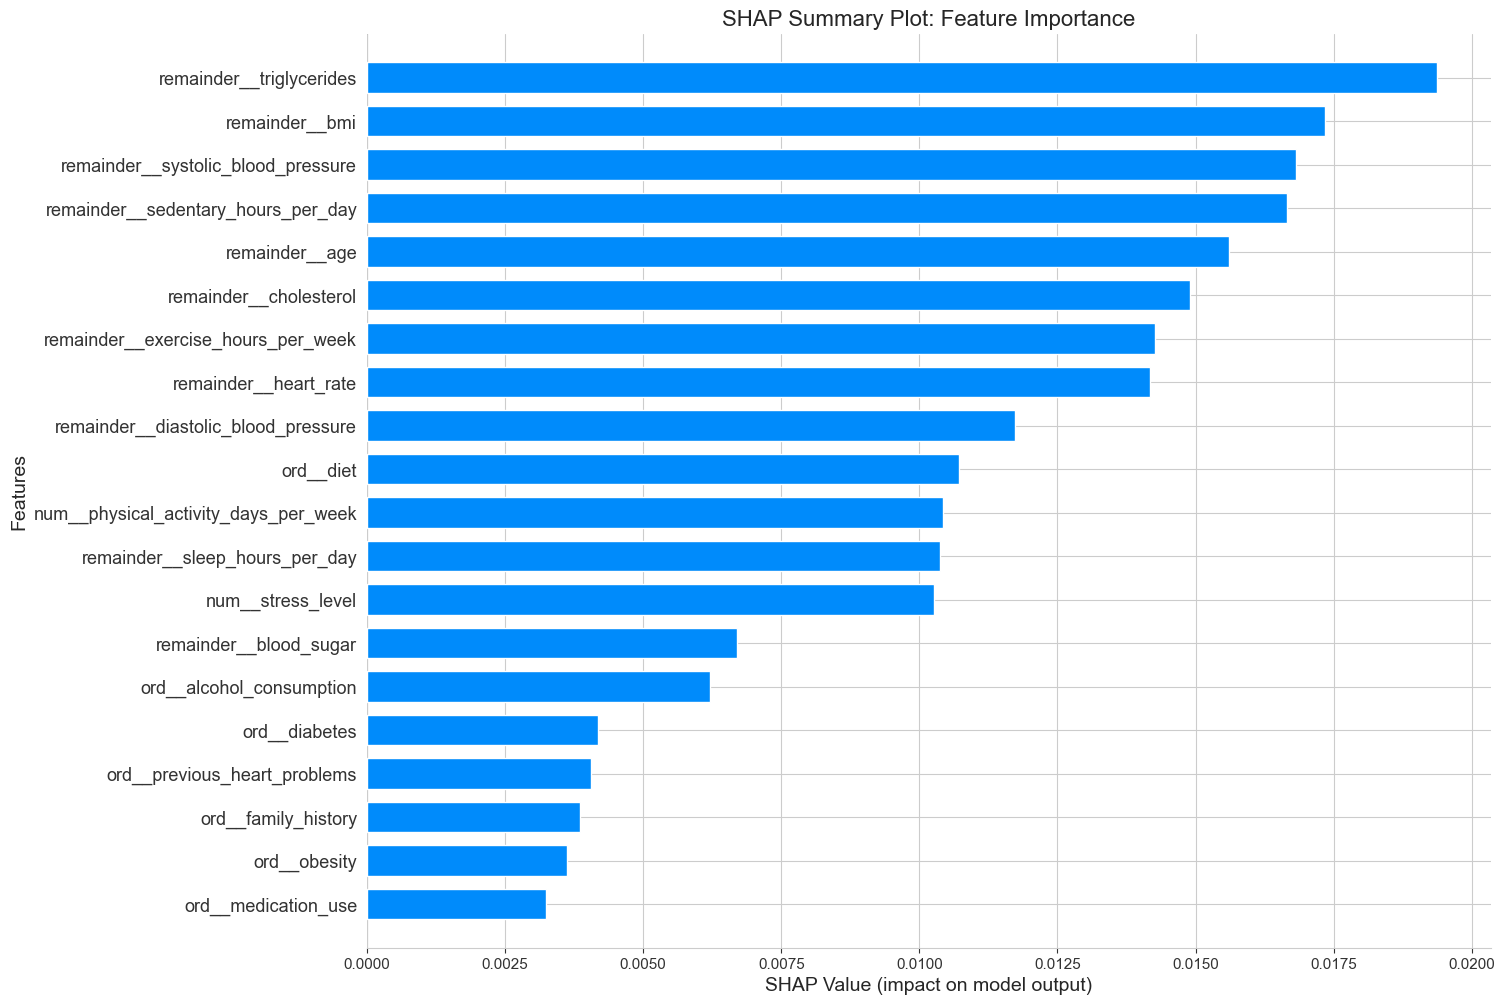

In [79]:
plt.rcParams.update({'font.size': 13})
rng = np.random.default_rng()
shap.summary_plot(
    shap_values [:,:,1], 
    X_train_processed, 
    plot_type="bar", 
    max_display=20, 
    plot_size=(15, 10), 
    rng=rng,
    show=False
)

fig, ax = plt.gcf(), plt.gca()
# настраиваем заголовок и оси
ax_title = 'SHAP Summary Plot: Feature Importance'
font_size = 16
ax.set_title(ax_title, fontdict={"size": font_size})
ax.set_xlabel('SHAP Value (impact on model output)', fontsize=14)
ax.set_ylabel('Features', fontsize=14)
# показываем график
plt.show()

**Выводы:**
Анализ важности признаков выявил следующие факторы, оказывающие наибольшее влияние на риск сердечного приступа:
* Уровень триглицерина.  Это форма жиров, которые поступают в организм с пищей, их повышенный уровень связан с риском инфаркта миокарда и других сердечно-сосудистых заболеваний.
* Индекс массы тела. Избыточный вес и ожирение повышают риск сердечно-сосудистых заболеваний, включая инфаркт миокарда.
* Систолическое кровяное давление
* Количество часов сидячего образа жизни и физической активности в неделю. Физическая активность снижает риск сердечного приступа.
* Возраст
* Уровень холестерина

## Подготовка предсказания на тестовой выборке

С помощью полученной лучшей модели сделаем предсказания на тестовой выборке

In [80]:
# копируем данные для дальнейшей работы
data_test = df_test.copy()
data_test = data_test.set_index('id')
data_test.head()

,age,cholesterol,heart_rate,diabetes,family_history,smoking,obesity,alcohol_consumption,exercise_hours_per_week,diet,previous_heart_problems,medication_use,stress_level,sedentary_hours_per_day,bmi,triglycerides,physical_activity_days_per_week,sleep_hours_per_day,blood_sugar,gender,systolic_blood_pressure,diastolic_blood_pressure
id,,,,,,,,,,,,,,,,,,,,,,
7746,0.494382,0.264286,0.062328,0,1,1,1,1,0.361618,2,0,0,8,0.194370,0.283490,0.306494,1,0.333333,0.227018,Male,0.283871,0.372093
4202,0.224719,0.953571,0.082493,1,0,0,1,0,0.996483,2,1,1,5,0.329888,0.467036,0.087013,0,0.166667,0.227018,Female,0.703226,0.441860
6632,0.629213,0.092857,0.064161,0,1,1,1,0,0.995561,0,0,0,10,0.780075,0.409366,0.205195,7,1.000000,0.102767,Male,0.458065,0.779070
4639,0.460674,0.567857,0.055912,1,1,1,1,1,0.437277,0,0,0,10,0.785071,0.910261,0.163636,0,0.666667,0.203557,Female,0.741935,0.255814
4825,0.719101,0.485714,0.022915,1,0,1,0,1,0.514920,0,0,0,7,0.070919,0.758924,0.580519,5,0.000000,0.227018,Male,0.412903,0.395349


In [81]:
X_test = data_test
best_model = randomized_search.best_estimator_
y_pred = best_model.predict(X_test)

# формируем датасет с результатами
results = pd.DataFrame({
    'id': X_test.index,        
    'prediction': y_pred
}).reset_index(drop=True)

print("Предсказания для тестового датасета:")
print(results)

Предсказания для тестового датасета:
       id  prediction
0    7746           0
1    4202           0
2    6632           0
3    4639           0
4    4825           0
..    ...         ...
961  9271           0
962  8012           1
963  2456           0
964  4984           0
965  6521           0

[966 rows x 2 columns]


In [82]:
# сохраняем в CSV
results.to_csv('predictions.csv', index=False)

In [83]:
# сохраняем пайплайн с моделью в отдельный файл
dump(best_model, 'app/best_model.joblib')

['app/best_model.joblib']

## Общий вывод

Целью работы была разработка  модели для предсказания риска сердечного приступа на основе данных пациентов.

Для этого были сделаны следущие шаги: 

**1. Загрузка данных**

Загружены и проанализированы датафреймы, в которых содержалась информация о пациентах: антропометрические данные пациентов, информация о привычках, давлении, наличиихронических заболеваний, биохимии крови, а также целевой признак - **риск  поражения сердца**.

**2. Предобработка данных**

Избавились от лишних входных признаков, которые либо не несли необходимой информации. Избавились от пропусков и неявных дубликатов, приведя данные к единообразной записи. Убедились в отсутствии явных дубликатов. Изменили типы данных там, где это было необходимо.

**3. Исследовательский анализ данных**

Были построены распределеления для тренировочной и тестовой выборок. Убедились, что они похожи. Также избавились от обнаруженных выбросов.

**4. Корреляционный анализ данных**

Убедились, что для тренировочной выборки корреляционная матрица почти не отличается от матрицы тренировочной выборки. Связь между целевым признаком и входными признаками слабая. 

**5. Обучение моделей**

С использованием пайплайнов была найдена лучшая модель для предсказания вероятности увольнения сотрудников.

При оценке качества модели использовалась метрика ROC-AUC, которая подходит для бинарной классификации с несбалансированной выборкой

В ходе работы были проанализированы 4 модели:

* KNeighborsClassifier
* DecisionTreeClassifier
* RandomForestClassifier
* CatBoost

Лучшей оказалась модель **RandomForestClassifier**. Преимущества это модели обусловлены её способностью улавливать сложные нелинейные зависимости между признаками и эффективно обрабатывать данные с большим количеством признаков.

**6. Анализ важности признаков**

Анализ важности признаков выявил, что на риск сердечного приступа сильнее всего влияют индекс массы тела и уровень триглицерина.

**7. Подготовка предсказания на тестовой выборке**

С помощью полученной лучшей модели сделали предсказания на тестовой выборке и записали результаты в SCV-файл.

**Таким образом, была получена модель со довольно слабой предсказательной способностью (ROC-AUC=0.59). Это может быть связано со слабой корреляцией входных признаков с целевым и недостаточным объемом данных. Для повышения качества прогноза необходимо дополнить набор данных ключевыми медицинскими показателями. Однако текущая модель может служить базой для дальнейшей доработки при участии медицинских экспертов и расширении датасета.**